# Physics-Informed vs. Hybrid ML: Richards Equation in a 1-D Soil Column

## Motivation

Unsaturated flow in soils is one of the most important—and computationally expensive—processes in hydrology. The Richards equation couples a nonlinear PDE with empirical **constitutive relationships** (the soil water retention curve and hydraulic conductivity function) that are highly uncertain and difficult to measure. This makes it a perfect testbed for understanding the spectrum of physics–ML integration strategies.

## What we will cover

1. **Physics solver** — the Celia & Zarba (1990) modified Picard scheme for Richards equation with van Genuchten constitutive relations
2. **PINN** — a Physics-Informed Neural Network that encodes Richards equation in its loss function
3. **Hybrid model** — keep the Picard solver but replace the *unknown* constitutive relationship with a learned feed-forward network

## Earth Science Connection

Accurate simulation of soil water movement underpins drought forecasting, irrigation management, contaminant transport, and land-surface modeling. Real soils have spatially heterogeneous, poorly measured constitutive curves — the hybrid approach lets us learn these curves from data while preserving physical mass conservation.

$$
\frac{\partial \theta}{\partial t} = \frac{\partial}{\partial z}\!\left[K(h)\left(\frac{\partial h}{\partial z} - 1\right)\right]
$$

where $h$ is the pressure head [m], $\theta$ is volumetric water content [-], $K(h)$ is unsaturated hydraulic conductivity [m/s], and $z$ is depth (positive downward) [m].


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

import torch
import torch.nn as nn
import torch.optim as optim

rng = np.random.default_rng(42)
torch.manual_seed(42)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


## 1. Van Genuchten Constitutive Relations

The van Genuchten (1980) model gives smooth, empirically validated relationships between pressure head $h$ and both water content $\theta$ and hydraulic conductivity $K$.

### Water retention curve

$$
\theta(h) = \theta_r + \frac{\theta_s - \theta_r}{\left[1 + |\alpha h|^n\right]^m}, \quad h < 0
$$

where $m = 1 - 1/n$, $\theta_r$ is residual water content, $\theta_s$ is saturated water content, $\alpha$ [1/m] is a pore-size parameter, and $n$ [-] controls the curve shape.

### Effective saturation

$$
S_e(h) = \frac{\theta - \theta_r}{\theta_s - \theta_r} = \frac{1}{\left[1 + |\alpha h|^n\right]^m}
$$

### Unsaturated hydraulic conductivity (Mualem, 1976)

$$
K(h) = K_s\, S_e^{1/2} \left[1 - \left(1 - S_e^{1/m}\right)^m\right]^2
$$

### Specific moisture capacity (needed by modified Picard)

$$
C(h) = \frac{d\theta}{dh} = \frac{\alpha n m (\theta_s - \theta_r)|\alpha h|^{n-1}}{\left[1 + |\alpha h|^n\right]^{m+1}}
$$


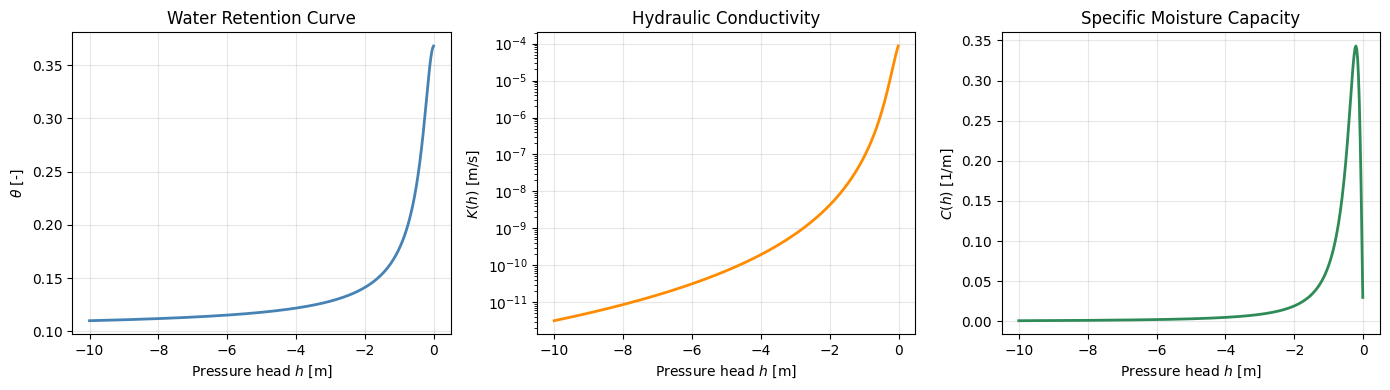

In [2]:
# Van Genuchten / Mualem parameters — Celia et al. (1990) "New Mexico" soil
# This is the canonical benchmark for the modified Picard scheme.
VG = dict(
    theta_r = 0.102,    # residual water content [-]
    theta_s = 0.368,    # saturated water content [-]
    alpha   = 3.35,     # [1/m]  (high alpha -> relatively coarse-grained)
    n       = 2.0,      # shape parameter [-]
    Ks      = 9.22e-5,  # saturated hydraulic conductivity [m/s]
)
VG['m'] = 1.0 - 1.0 / VG['n']


def Se(h, p=VG):
    """Effective saturation; h <= 0 (unsaturated), returns 1 for h >= 0."""
    h = np.asarray(h, dtype=float)
    Se_val = np.where(h >= 0, 1.0,
                      (1.0 + (p['alpha'] * np.abs(h)) ** p['n']) ** (-p['m']))
    return np.clip(Se_val, 0.0, 1.0)


def theta(h, p=VG):
    """Volumetric water content."""
    return p['theta_r'] + (p['theta_s'] - p['theta_r']) * Se(h, p)


def K(h, p=VG):
    """Unsaturated hydraulic conductivity [m/s] (Mualem, 1976)."""
    Se_val = Se(h, p)
    K_val = p['Ks'] * Se_val**0.5 * (1.0 - (1.0 - Se_val**(1.0/p['m']))**p['m'])**2
    return K_val


def C(h, p=VG):
    """Specific moisture capacity dtheta/dh [1/m]."""
    h = np.asarray(h, dtype=float)
    ah = p['alpha'] * np.abs(h)
    num = p['alpha'] * p['n'] * p['m'] * (p['theta_s'] - p['theta_r']) * ah**(p['n']-1)
    den = (1.0 + ah**p['n'])**(p['m'] + 1)
    C_val = np.where(h >= 0, 0.0, num / den)
    return C_val


# ---- Visualize constitutive curves ----------------------------------------
h_plot = np.linspace(-10, -0.01, 400)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(h_plot, theta(h_plot), color='steelblue', lw=2)
axes[0].set_xlabel('Pressure head $h$ [m]')
axes[0].set_ylabel(r'$\theta$ [-]')
axes[0].set_title('Water Retention Curve')

axes[1].semilogy(h_plot, K(h_plot), color='darkorange', lw=2)
axes[1].set_xlabel('Pressure head $h$ [m]')
axes[1].set_ylabel(r'$K(h)$ [m/s]')
axes[1].set_title('Hydraulic Conductivity')

axes[2].plot(h_plot, C(h_plot), color='seagreen', lw=2)
axes[2].set_xlabel('Pressure head $h$ [m]')
axes[2].set_ylabel(r'$C(h)$ [1/m]')
axes[2].set_title('Specific Moisture Capacity')

plt.tight_layout()
plt.show()


## 2. The Celia-Zarba Modified Picard Solver

Richards equation is notoriously stiff and difficult to solve numerically. Celia et al. (1990) showed that a **modified Picard iteration** written in terms of pressure head $h$ maintains mass conservation while avoiding the instabilities of the standard Newton approach.

### Discretisation

We use finite differences on a uniform grid with $N$ nodes, spacing $\Delta z$, and time step $\Delta t$. The $h$-based form of Richards equation is:

$$
C(h)\frac{\partial h}{\partial t} = \frac{\partial}{\partial z}\!\left[K(h)\left(\frac{\partial h}{\partial z} - 1\right)\right]
$$

### Modified Picard linearisation

At iteration $m+1$ within time step $n \to n+1$, expand $\theta$ about the current iterate $h^{m}$:

$$
\theta^{m+1} \approx \theta^m + C^m (h^{m+1} - h^m)
$$

Substituting and writing $\delta h_i = h_i^{m+1} - h_i^m$, discretising the flux term **implicitly** yields a **tridiagonal linear system** at each Picard iteration:

$$
\underbrace{\left(\frac{C_i^m}{\Delta t} + \frac{K_{i+1/2}^m + K_{i-1/2}^m}{\Delta z^2}\right)}_{\text{diagonal}}\delta h_i
- \frac{K_{i+1/2}^m}{\Delta z^2}\delta h_{i+1}
- \frac{K_{i-1/2}^m}{\Delta z^2}\delta h_{i-1}
= r_i^m
$$

where the right-hand side collects the explicit flux divergence, gravity, and mass residual:

$$
r_i^m = \frac{K_{i+1/2}^m(h_{i+1}^m - h_i^m) - K_{i-1/2}^m(h_i^m - h_{i-1}^m)}{\Delta z^2}
       - \frac{K_{i+1/2}^m - K_{i-1/2}^m}{\Delta z}
       - \frac{\theta_i^m - \theta_i^n}{\Delta t}
$$

This system is solved with the **Thomas algorithm** (banded LU) at each Picard iteration. Treating the flux terms implicitly is essential for stability at sharp fronts — a pointwise update (ignoring off-diagonal coupling) diverges for the Celia et al. problem.

### Celia et al. (1990) benchmark setup

This is the canonical test problem for Richards equation solvers (reproduced in Clark et al. 2021, Fig. 2):

- **Column**: 0.6 m, 100 uniform layers
- **Simulation**: 60 hours
- **Top BC**: $h(0, t) = -0.75$ m (near-saturated surface)
- **Bottom BC**: $h(0.6, t) = -10$ m (dry)
- **Initial condition**: thin wet layer at surface, dry bulk below

$$
h(z, 0) = \begin{cases} -0.75 - 9.25\,z & z \le 0.006\text{ m} \\ -10 & z > 0.006\text{ m} \end{cases}
$$

The sharp contrast between the wet top and dry bulk drives a **strongly nonlinear infiltration front** that propagates downward — a much more demanding test than a smooth initial profile.


In [3]:
# ---- Grid and simulation parameters (Celia et al. 1990 benchmark) --------
L      = 0.6      # column depth [m]
N      = 100      # number of nodes
dz     = L / (N - 1)
z_grid = np.linspace(0, L, N)  # depth [m], 0 = surface

dt      = 60.0         # time step [s]
T_end   = 60 * 3600.0  # 60 hours [s]
n_steps = int(T_end / dt)

# Constant-head Dirichlet boundary conditions
h_top = -0.75   # [m]  near-saturated surface
h_bot = -10.0   # [m]  dry bottom

# Initial condition: thin wet layer at surface, dry bulk (Celia et al. 1990)
h_init = np.where(z_grid <= 0.006, -0.75 - 9.25 * z_grid, -10.0)

MAX_ITER = 50
TOL      = 1e-6


def inter_K(h, p=VG):
    """Arithmetic-mean inter-nodal conductivity; returns array of length N-1."""
    return 0.5 * (K(h[:-1], p) + K(h[1:], p))


def picard_step(h_m, theta_n, dt, dz, p=VG):
    """
    One modified-Picard iteration using a tridiagonal (banded) linear solve.

    Flux terms are treated implicitly so the scheme is stable at the sharp
    infiltration front. scipy.linalg.solve_banded runs the Thomas algorithm
    in O(N) work.

    Returns (h_new, max_abs_delta_h).
    """
    N_loc = len(h_m)
    ni    = N_loc - 2   # interior nodes

    Km  = inter_K(h_m, p)  # (N-1,)
    Cm  = C(h_m, p)         # (N,)
    thm = theta(h_m, p)     # (N,)

    diag  = np.empty(ni)
    upper = np.empty(ni - 1)
    lower = np.empty(ni - 1)
    rhs   = np.empty(ni)

    for k in range(ni):
        i   = k + 1           # global node index
        Kp  = Km[i]           # K_{i+1/2}
        Km_ = Km[i - 1]       # K_{i-1/2}

        diag[k] = max(Cm[i], 1e-14) / dt + (Kp + Km_) / dz**2
        if k < ni - 1:
            upper[k]     = -Kp  / dz**2
        if k > 0:
            lower[k - 1] = -Km_ / dz**2

        flux_div = (Kp*(h_m[i+1] - h_m[i]) - Km_*(h_m[i] - h_m[i-1])) / dz**2
        grav     = (Kp - Km_) / dz
        rhs[k]   = flux_div - grav - (thm[i] - theta_n[i]) / dt

    # scipy banded format: row 0 = superdiagonal, row 1 = diagonal, row 2 = subdiagonal
    ab = np.zeros((3, ni))
    ab[0, 1:]  = upper
    ab[1, :]   = diag
    ab[2, :-1] = lower

    dh_int = solve_banded((1, 1), ab, rhs)

    h_new = h_m.copy()
    h_new[1:-1] += dh_int
    h_new[0]  = h_top
    h_new[-1] = h_bot
    return h_new, np.max(np.abs(dh_int))


def run_richards(h0, dt, dz, n_steps, p=VG, store_every=20):
    """Full Celia-Zarba simulation. Returns (h_snapshots, theta_snapshots, times)."""
    h = h0.copy()
    h[0] = h_top; h[-1] = h_bot

    h_store  = [h.copy()]
    th_store = [theta(h, p)]
    t_store  = [0.0]

    for step in range(n_steps):
        theta_old = theta(h, p)
        h_iter = h.copy()

        for _ in range(MAX_ITER):
            h_iter, err = picard_step(h_iter, theta_old, dt, dz, p)
            if err < TOL:
                break

        h = h_iter
        if (step + 1) % store_every == 0:
            h_store.append(h.copy())
            th_store.append(theta(h, p))
            t_store.append((step + 1) * dt)

    return np.array(h_store), np.array(th_store), np.array(t_store)


print(f'Running Celia et al. (1990) benchmark: {n_steps} steps x {dt:.0f}s = {T_end/3600:.0f} h')
h_ref, th_ref, t_ref = run_richards(h_init, dt, dz, n_steps)
print(f'Output snapshots: {h_ref.shape[0]}')


Running Celia et al. (1990) benchmark: 3600 steps x 60s = 60 h
Output snapshots: 181


### 2.1 Simulation Results


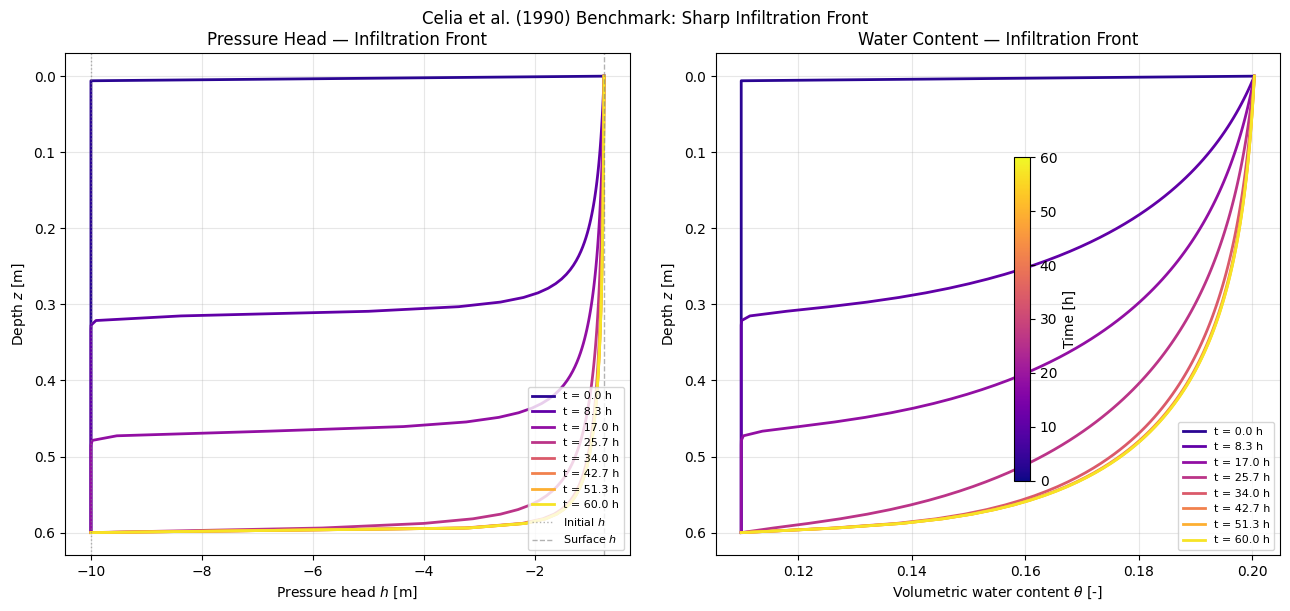

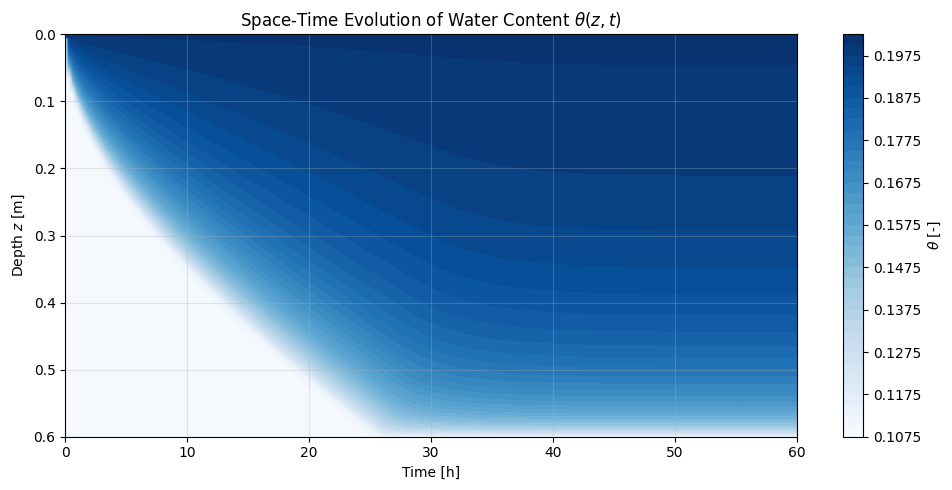

In [ ]:
# ---- Plot pressure head profiles — infiltration front advancing downward --
# Select 8 evenly-spaced snapshots to overlay
n_out    = h_ref.shape[0]
snap_idx = np.linspace(0, n_out - 1, 8, dtype=int)
cmap     = plt.cm.plasma
colors   = cmap(np.linspace(0.05, 0.95, len(snap_idx)))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ci, i in enumerate(snap_idx):
    lbl = f't = {t_ref[i]/3600:.1f} h'
    axes[0].plot(h_ref[i],  z_grid, color=colors[ci], lw=2, label=lbl)
    axes[1].plot(th_ref[i], z_grid, color=colors[ci], lw=2, label=lbl)

# Annotate the infiltration front on the h panel
axes[0].axvline(-10, color='grey', ls=':', lw=1, alpha=0.6, label='Initial $h$')
axes[0].axvline(-0.75, color='grey', ls='--', lw=1, alpha=0.6, label='Surface $h$')

for ax in axes:
    ax.invert_yaxis()
    ax.set_ylabel('Depth $z$ [m]')

axes[0].set_xlabel('Pressure head $h$ [m]')
axes[0].set_title('Pressure Head — Infiltration Front')
axes[0].legend(fontsize=8, loc='lower right')

axes[1].set_xlabel(r'Volumetric water content $\theta$ [-]')
axes[1].set_title('Water Content — Infiltration Front')
axes[1].legend(fontsize=8, loc='lower right')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, T_end/3600))
sm.set_array([])
#fig.colorbar(sm, ax=axes, label='Time [h]', shrink=0.7, pad=0.02)

plt.tight_layout()
plt.suptitle('Celia et al. (1990) Benchmark: Sharp Infiltration Front', y=1.01, fontsize=12)
plt.show()

# ---- Space-time heatmap of water content ----------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.contourf(
    t_ref / 3600, z_grid, th_ref.T,
    levels=40, cmap='Blues'
)
ax.invert_yaxis()
ax.set_xlabel('Time [h]')
ax.set_ylabel('Depth $z$ [m]')
ax.set_title(r'Space-Time Evolution of Water Content $\theta(z, t)$')
cb = fig.colorbar(im, ax=ax, label=r'$\theta$ [-]')
plt.tight_layout()
plt.show()


## 3. Physics-Informed Neural Network (PINN)

A PINN trains a network $\hat{h}(z, t; \boldsymbol{\theta})$ by minimising a composite loss with three terms:

$$
\mathcal{L} = \mathcal{L}_{\text{IC}} + \mathcal{L}_{\text{BC}} + \mathcal{L}_{\text{PDE}}
$$

**Initial condition loss** (enforce $h(z,0)$ from the linear initial profile):
$$
\mathcal{L}_{\text{IC}} = \frac{1}{N_{IC}}\sum_i \left[\hat{h}(z_i, 0) - h_0(z_i)\right]^2
$$

**Boundary condition loss** (enforce constant head at top and bottom for all $t$):
$$
\mathcal{L}_{\text{BC}} = \frac{1}{N_{BC}}\sum_k \left[\hat{h}(0, t_k) - h_{\text{top}}\right]^2 + \left[\hat{h}(L, t_k) - h_{\text{bot}}\right]^2
$$

**PDE residual loss** (enforce Richards equation at collocation points via autograd):
$$
\mathcal{L}_{\text{PDE}} = \frac{1}{N_{col}}\sum_{i,k}\left[C(\hat{h})\frac{\partial \hat{h}}{\partial t} - \frac{\partial}{\partial z}\left(K(\hat{h})\left(\frac{\partial \hat{h}}{\partial z} - 1\right)\right)\right]^2
$$

Spatial and temporal derivatives in $\mathcal{L}_{\text{PDE}}$ are computed with **automatic differentiation** — no finite differences needed in the loss.


In [5]:
# ---- Van Genuchten functions in PyTorch (for autograd through the PDE loss)
_p = VG

def Se_torch(h):
    ah = _p['alpha'] * torch.abs(h)
    Se_val = (1.0 + ah ** _p['n']) ** (-_p['m'])
    return torch.where(h >= 0, torch.ones_like(h), Se_val).clamp(1e-8, 1.0)

def theta_torch(h):
    return _p['theta_r'] + (_p['theta_s'] - _p['theta_r']) * Se_torch(h)

def K_torch(h):
    Se_val = Se_torch(h)
    inner  = (1.0 - Se_val ** (1.0 / _p['m'])).clamp(0.0, 1.0)
    return _p['Ks'] * Se_val ** 0.5 * (1.0 - inner ** _p['m']) ** 2

def C_torch(h):
    """
    Analytical specific moisture capacity dtheta/dh.

    Using the closed-form expression avoids calling .backward() inside the
    loss function (which would conflict with create_graph=True in the outer
    autograd call and cause NaN losses).
    """
    ah  = _p['alpha'] * torch.abs(h)
    num = (_p['alpha'] * _p['n'] * _p['m']
           * (_p['theta_s'] - _p['theta_r'])
           * ah ** (_p['n'] - 1))
    den = (1.0 + ah ** _p['n']) ** (_p['m'] + 1)
    return torch.where(h >= 0, torch.zeros_like(h), num / den).clamp(min=0.0)


# ---- PINN architecture ---------------------------------------------------
class PINN(nn.Module):
    """
    Fully-connected network mapping (z, t) -> h.

    Output is constrained to [h_bot, h_top] via a scaled sigmoid so that
    K(h) never evaluates outside the physical range — preventing gradient
    explosions in the PDE residual loss.
    """
    def __init__(self, hidden=64, n_layers=5):
        super().__init__()
        dims = [2] + [hidden] * n_layers + [1]
        seq = []
        for i in range(len(dims) - 1):
            seq.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                seq.append(nn.Tanh())
        self.net = nn.Sequential(*seq)
        self.register_buffer('z_scale', torch.tensor(L,          dtype=torch.float32))
        self.register_buffer('t_scale', torch.tensor(float(T_end), dtype=torch.float32))
        # Physical h bounds for output clipping
        self.h_lo = h_bot
        self.h_hi = h_top

    def forward(self, z, t):
        z_n = z / self.z_scale
        t_n = t / self.t_scale
        x   = torch.stack([z_n, t_n], dim=1)     # (N, 2)
        raw = self.net(x).squeeze(-1)             # (N,)
        # Sigmoid maps raw -> (h_bot, h_top), keeping h in the physical range
        return self.h_lo + (self.h_hi - self.h_lo) * torch.sigmoid(raw)


pinn = PINN(hidden=64, n_layers=5).to(device)
n_params = sum(p.numel() for p in pinn.parameters())
print(f'PINN parameters: {n_params:,}')


PINN parameters: 16,897


In [6]:
# A reference conductivity scale for normalising the PDE residual.
# Dividing by K_ref prevents the loss being dominated by near-dry regions
# where K ~ 1e-12 and the residual magnitude is tiny but gradients are huge.
K_REF = float(VG['Ks'])   # [m/s]


def pinn_losses(model, n_col=2000, n_bc=300, n_ic=200):
    """Compute IC, BC, and PDE residual losses for the Celia et al. scenario."""
    # -- Initial condition (sharp IC matching Celia et al.) --
    z_ic = torch.linspace(0, L, n_ic, device=device, dtype=torch.float32)
    t_ic = torch.zeros(n_ic, device=device, dtype=torch.float32)
    z_np = z_ic.cpu().numpy()
    import numpy as np
    h_ic_np = np.where(z_np <= 0.006, -0.75 - 9.25 * z_np, -10.0).astype(np.float32)
    h_ic_true = torch.tensor(h_ic_np, device=device)
    L_ic = torch.mean((model(z_ic, t_ic) - h_ic_true) ** 2)

    # -- Boundary conditions --
    t_bc = torch.rand(n_bc, device=device) * T_end
    z_top_bc = torch.zeros(n_bc, device=device)
    z_bot_bc = torch.full((n_bc,), L, device=device)
    L_bc = (torch.mean((model(z_top_bc, t_bc) - h_top) ** 2)
            + torch.mean((model(z_bot_bc, t_bc) - h_bot) ** 2))

    # -- PDE residual at interior collocation points --
    # Sample t with a square-root bias so early times (active front) get more
    # collocation points than late times (near steady state).
    z_col = (torch.rand(n_col, device=device) * (L - 2*dz) + dz).requires_grad_(True)
    u_t   = torch.rand(n_col, device=device)
    t_col = (u_t ** 2 * T_end).requires_grad_(True)   # sqrt bias -> denser at small t

    h_col = model(z_col, t_col)

    grad_h    = torch.autograd.grad(h_col.sum(), [z_col, t_col], create_graph=True)
    dh_dz     = grad_h[0]
    dh_dt     = grad_h[1]

    K_h       = K_torch(h_col)
    flux      = K_h * (dh_dz - 1.0)
    d_flux_dz = torch.autograd.grad(flux.sum(), z_col, create_graph=True)[0]

    C_h       = C_torch(h_col)
    residual  = C_h * dh_dt - d_flux_dz

    # Normalise by K_REF so residual is dimensionless regardless of how dry
    # the collocation point is
    L_pde = torch.mean((residual / K_REF) ** 2)

    return L_ic, L_bc, L_pde


In [7]:
N_EPOCHS_PINN  = 5000
W_IC, W_BC, W_PDE = 10.0, 10.0, 1.0

optimizer_pinn = optim.Adam(pinn.parameters(), lr=5e-4)
scheduler_pinn = optim.lr_scheduler.StepLR(optimizer_pinn, step_size=1000, gamma=0.5)

loss_hist = {'total': [], 'ic': [], 'bc': [], 'pde': []}

for epoch in range(N_EPOCHS_PINN):
    optimizer_pinn.zero_grad()
    L_ic, L_bc, L_pde = pinn_losses(pinn)
    loss = W_IC * L_ic + W_BC * L_bc + W_PDE * L_pde

    if torch.isnan(loss):
        print(f'NaN loss at epoch {epoch} — skipping step')
        continue

    loss.backward()
    # Clip gradients to prevent spikes near the front
    torch.nn.utils.clip_grad_norm_(pinn.parameters(), max_norm=1.0)
    optimizer_pinn.step()
    scheduler_pinn.step()

    if epoch % 100 == 0:
        loss_hist['total'].append(loss.item())
        loss_hist['ic'].append(L_ic.item())
        loss_hist['bc'].append(L_bc.item())
        loss_hist['pde'].append(L_pde.item())
        if epoch % 500 == 0:
            print(f'Epoch {epoch:5d} | total={loss.item():.4e} | '
                  f'IC={L_ic.item():.3e}  BC={L_bc.item():.3e}  PDE={L_pde.item():.3e}')

print('PINN training complete.')


Epoch     0 | total=6.1551e+02 | IC=1.846e+01  BC=4.309e+01  PDE=1.602e-10
Epoch   500 | total=2.0019e+00 | IC=1.522e-01  BC=1.005e-02  PDE=3.793e-01
Epoch  1000 | total=7.1383e-01 | IC=5.370e-02  BC=7.317e-03  PDE=1.037e-01
Epoch  1500 | total=4.7858e-01 | IC=3.219e-02  BC=6.492e-03  PDE=9.171e-02
Epoch  2000 | total=2.0354e-01 | IC=1.334e-02  BC=4.580e-03  PDE=2.438e-02
Epoch  2500 | total=1.3531e-01 | IC=6.099e-03  BC=3.159e-03  PDE=4.273e-02
Epoch  3000 | total=1.2190e-01 | IC=5.596e-03  BC=3.540e-03  PDE=3.054e-02
Epoch  3500 | total=9.4017e-02 | IC=4.878e-03  BC=3.411e-03  PDE=1.113e-02
Epoch  4000 | total=1.1288e-01 | IC=4.740e-03  BC=2.079e-03  PDE=4.469e-02
Epoch  4500 | total=1.4054e-01 | IC=3.704e-03  BC=3.962e-03  PDE=6.388e-02
PINN training complete.


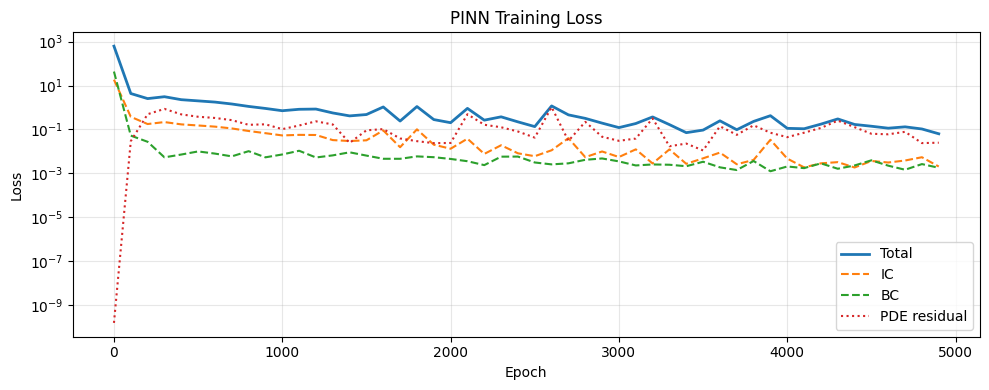

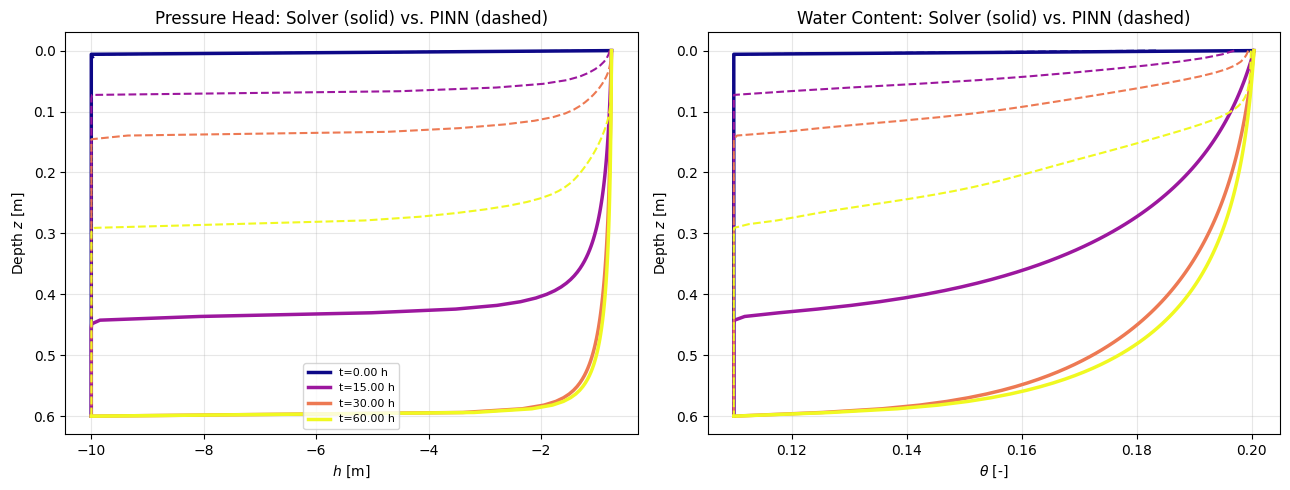

In [8]:
# Loss curves
epochs_logged = np.arange(0, N_EPOCHS_PINN, 100)
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(epochs_logged, loss_hist['total'], label='Total', lw=2)
ax.semilogy(epochs_logged, loss_hist['ic'],    label='IC', ls='--')
ax.semilogy(epochs_logged, loss_hist['bc'],    label='BC', ls='--')
ax.semilogy(epochs_logged, loss_hist['pde'],   label='PDE residual', ls=':')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('PINN Training Loss'); ax.legend()
plt.tight_layout(); plt.show()

# Compare PINN vs. reference at selected times
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_times = [0, len(t_ref)//4, len(t_ref)//2, -1]
cmap2  = plt.cm.plasma
colors2 = cmap2(np.linspace(0, 1, len(plot_times)))

with torch.no_grad():
    for ci, ti in enumerate(plot_times):
        t_val = float(t_ref[ti])
        color = colors2[ci]
        lbl   = f't={t_val/3600:.2f} h'

        axes[0].plot(h_ref[ti],  z_grid, color=color, lw=2.5, label=lbl)
        axes[1].plot(th_ref[ti], z_grid, color=color, lw=2.5, label=lbl)

        z_q = torch.tensor(z_grid, dtype=torch.float32, device=device)
        t_q = torch.full_like(z_q, t_val)
        h_pinn_pred  = pinn(z_q, t_q).cpu().numpy()
        th_pinn_pred = theta(h_pinn_pred)
        axes[0].plot(h_pinn_pred,  z_grid, color=color, lw=1.5, ls='--')
        axes[1].plot(th_pinn_pred, z_grid, color=color, lw=1.5, ls='--')

for ax in axes:
    ax.invert_yaxis(); ax.set_ylabel('Depth $z$ [m]')

axes[0].set_xlabel('$h$ [m]')
axes[0].set_title('Pressure Head: Solver (solid) vs. PINN (dashed)')
axes[0].legend(fontsize=8)
axes[1].set_xlabel(r'$\theta$ [-]')
axes[1].set_title('Water Content: Solver (solid) vs. PINN (dashed)')
plt.tight_layout(); plt.show()


## 4. Hybrid Model: Learning the Constitutive Relationship from Trajectories

The PINN approach in Section 3 encodes the full Richards equation (including the known constitutive relations) in its loss. But what if we don't know $\theta(h)$ or $K(h)$? This is realistic: laboratory measurements of soil water retention curves are expensive, spatially variable, and often unavailable.

The **hybrid** strategy keeps the Picard solver intact — preserving mass conservation and the correct PDE structure — but replaces the constitutive relationships with a small learned network $f_\phi(h)$. Crucially, we **do not supervise $f_\phi$ on known $(h, \theta, K, C)$ pairs**. Instead, we train purely from the observed time evolution of the pressure head field.

### Training signal

Given a sequence of reference pressure snapshots $\{h^{(k)}(z)\}_{k=0}^{T}$ (from sensors or, here, the reference simulation), we unroll the differentiable Picard solver for $S$ time steps and minimise

$$
\mathcal{L}_{\text{traj}} = \frac{1}{S} \sum_{s=1}^{S} \| h^{\text{sim}}_{s} - h^{\text{ref}}_{s} \|^2
$$

Gradients flow from $\mathcal{L}_{\text{traj}}$ back through the Thomas-algorithm solve at each Picard iteration, and then into $f_\phi$ — so the network learns whichever constitutive relationship makes the solver reproduce the observed dynamics.

### What we keep (physics)
- Modified Picard iteration: mass-conservative, correct PDE structure
- Correct boundary conditions at every step

### What we learn (data-driven)
A feed-forward network $f_\phi(h) \to (\hat{\theta}, \hat{K}, \hat{C})$ with physically-constrained output heads, trained **only** from pressure head trajectories — no constitutive data.


In [19]:
class ConstitutiveNet(nn.Module):
    """
    Small MLP: h -> (theta, K, C).

    Output heads enforce physical constraints without requiring supervision:
      - theta via sigmoid scaled to [theta_r, theta_s]
      - K    via exp anchored at Ks  (always positive)
      - C    via softplus            (always positive)

    The network is trained purely from observed pressure-head trajectories;
    it learns the constitutive relationship implicitly by making the Picard
    solver reproduce the correct dynamics.
    """
    def __init__(self, hidden=32):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.head_theta = nn.Linear(hidden, 1)
        self.head_logK  = nn.Linear(hidden, 1)
        self.head_C     = nn.Linear(hidden, 1)

    def forward(self, h):
        h_n  = h / abs(h_bot)   # normalise to ~ [-1, 0]
        feat = self.trunk(h_n.unsqueeze(-1))
        th_out = (VG['theta_r']
                  + (VG['theta_s'] - VG['theta_r'])
                  * torch.sigmoid(self.head_theta(feat)).squeeze(-1))
        K_out  = VG['Ks'] * torch.exp(self.head_logK(feat)).squeeze(-1)
        C_out  = nn.functional.softplus(self.head_C(feat)).squeeze(-1) * 0.5
        return th_out, K_out, C_out


def thomas_solve_torch(lower, diag, upper, rhs):
    """
    Differentiable Thomas (tridiagonal) algorithm — fully out-of-place.

    In-place index assignments (w[i] = ...) corrupt PyTorch's autograd
    version counter and cause RuntimeError during backward.  Instead we
    accumulate intermediate values in plain Python lists and call
    torch.stack at the end, which keeps every tensor leaf intact.

    All inputs are 1-D tensors of length n.
    lower[0] and upper[-1] are unused.
    """
    n = diag.shape[0]

    # Forward sweep: build w and d as lists of scalar tensors
    w_list = [diag[0]]
    d_list = [rhs[0]]
    for i in range(1, n):
        m = lower[i] / w_list[i - 1]
        w_list.append(diag[i]  - m * upper[i - 1])
        d_list.append(rhs[i]   - m * d_list[i - 1])

    w = torch.stack(w_list)   # (n,)
    d = torch.stack(d_list)   # (n,)

    # Back substitution: same pattern — accumulate into a list
    x_list = [None] * n
    x_list[-1] = d[-1] / w[-1]
    for i in range(n - 2, -1, -1):
        x_list[i] = (d[i] - upper[i] * x_list[i + 1]) / w[i]

    return torch.stack(x_list)


def picard_step_learned(h_m, theta_n, dt, dz, net):
    """
    One modified-Picard iteration using the learned constitutive net.
    Gradients flow back through the Thomas solve into net parameters.
    """
    N_loc = h_m.shape[0]
    ni    = N_loc - 2

    th_m, K_m, C_m = net(h_m)
    Km  = 0.5 * (K_m[:-1] + K_m[1:])
    Kp  = Km[1:];   Km_ = Km[:-1]
    Ci  = C_m[1:-1].clamp(min=1e-14)

    diag  = Ci / dt + (Kp + Km_) / dz**2
    upper = -Kp  / dz**2
    lower = -Km_ / dz**2

    h_int   = h_m[1:-1];  h_above = h_m[:-2];  h_below = h_m[2:]
    flux_div = (Kp*(h_below - h_int) - Km_*(h_int - h_above)) / dz**2
    grav     = (Kp - Km_) / dz
    rhs      = flux_div - grav - (th_m[1:-1] - theta_n[1:-1]) / dt

    dh_int = thomas_solve_torch(lower, diag, upper, rhs)

    h_new = torch.cat([
        torch.tensor([h_top], device=h_m.device, dtype=h_m.dtype),
        h_m[1:-1] + dh_int,
        torch.tensor([h_bot], device=h_m.device, dtype=h_m.dtype),
    ])
    return h_new, dh_int.abs().max()


const_net = ConstitutiveNet(hidden=32).to(device)
print(f'ConstitutiveNet parameters: {sum(p.numel() for p in const_net.parameters()):,}')


ConstitutiveNet parameters: 2,275


Generating dense training snapshots (store_every=1)...
Dense snapshots: 181  (every 60 s)
Epoch     0 | loss=8.5552e+01 | lr=1.00e-03
Epoch   200 | loss=9.7962e-01 | lr=9.78e-04
Epoch   400 | loss=3.0508e+00 | lr=9.14e-04
Epoch   600 | loss=1.9345e-02 | lr=8.14e-04
Epoch   800 | loss=2.5534e-02 | lr=6.88e-04
Epoch  1000 | loss=1.7993e-02 | lr=5.49e-04
Epoch  1200 | loss=1.7047e-02 | lr=4.10e-04
Epoch  1400 | loss=1.7419e-02 | lr=2.85e-04
Epoch  1600 | loss=1.3210e-02 | lr=1.86e-04
Epoch  1800 | loss=2.4120e-02 | lr=1.22e-04
Training complete.


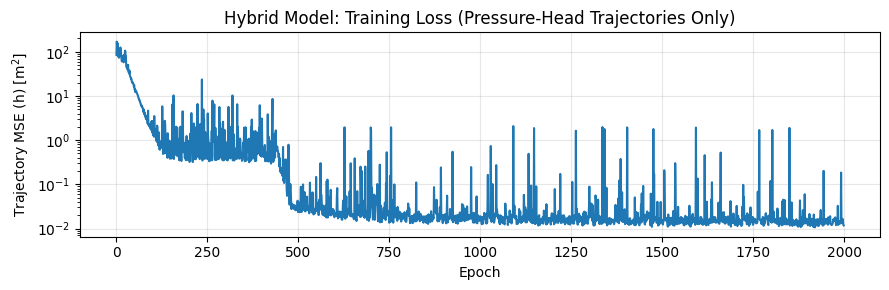

In [20]:
# ---- Generate a dense training dataset (every time step) ----------------
#
# The reference snapshots used for visualisation are stored every 20 steps
# (dt_snap = 1200 s).  Training with inner_steps=20 means unrolling through
# 20 sequential Thomas solves per unroll step, creating a computation graph
# ~240 nodes deep — gradients vanish before reaching the network weights.
#
# Instead we run a shorter dense simulation (first 3 h, every step = 60 s)
# so that inner_steps=1.  Each gradient update unrolls only UNROLL_STEPS
# consecutive solver steps, keeping the graph shallow and gradients healthy.

T_train   = 3 * 3600.0           # first 3 h — where the front is most active
n_train   = int(T_train / dt)    # 180 time steps

print('Generating dense training snapshots (store_every=1)...')
h_tr_dense, _, t_tr_dense = run_richards(
    h_init, dt, dz, n_train, store_every=1
)
print(f'Dense snapshots: {h_tr_dense.shape[0]}  (every {dt:.0f} s)')

h_tr_t = torch.tensor(h_tr_dense, dtype=torch.float32, device=device)  # (n_train+1, N)


# ---- Train from pressure-head trajectories only --------------------------
#
# At each epoch we pick a random starting snapshot, advance the differentiable
# Picard solver for UNROLL_STEPS consecutive time steps (each dt=60 s), and
# minimise MSE against the reference h profiles.
#
# No constitutive supervision — theta(h), K(h), C(h) are inferred entirely
# from the dynamics of the propagating infiltration front.
#
# Gradient flow:
#   loss -> h_sim -> picard_step_learned -> [K_m, C_m, th_m]  <- net(h_m)    (current iterate)
#                                        -> theta_n            <- net(h_prev) (old time level)
#
# theta_n must NOT be detached: the time-derivative term (th_m - theta_n)/dt
# in the RHS is the primary signal for learning the water retention curve theta(h).

n_snap_tr   = h_tr_t.shape[0]
UNROLL_STEPS = 8    # consecutive solver steps per gradient update
PICARD_ITERS = 3    # Picard iterations per step
N_EPOCHS     = 2000
LR           = 1e-3

const_net = ConstitutiveNet(hidden=32).to(device)  # fresh initialisation
opt       = optim.Adam(const_net.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS, eta_min=1e-4)

traj_losses = []

for epoch in range(N_EPOCHS):
    opt.zero_grad()

    start_idx = int(rng.integers(0, max(1, n_snap_tr - UNROLL_STEPS - 1)))
    h_curr    = h_tr_t[start_idx].clone()   # IC for this window (detached from ref data)
    total_loss = torch.zeros(1, device=device)

    for s in range(UNROLL_STEPS):
        target_idx = start_idx + s + 1
        if target_idx >= n_snap_tr:
            break

        # theta at the OLD time level — evaluated at h_curr, kept in the graph
        # so gradients flow through the (th_m - theta_n)/dt term in the RHS.
        theta_old = const_net(h_curr)[0]

        # PICARD_ITERS iterations to advance one dt=60 s time step
        for _ in range(PICARD_ITERS):
            h_curr, _ = picard_step_learned(h_curr, theta_old, dt, dz, const_net)

        total_loss = total_loss + torch.mean((h_curr - h_tr_t[target_idx]) ** 2)

    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(const_net.parameters(), 1.0)
    opt.step()
    scheduler.step()

    traj_losses.append(total_loss.item())
    if epoch % 200 == 0:
        print(f'Epoch {epoch:5d} | loss={total_loss.item():.4e} | '
              f'lr={scheduler.get_last_lr()[0]:.2e}')

print('Training complete.')

fig, ax = plt.subplots(figsize=(9, 3))
ax.semilogy(traj_losses)
ax.set_xlabel('Epoch')
ax.set_ylabel('Trajectory MSE (h) [m$^2$]')
ax.set_title('Hybrid Model: Training Loss (Pressure-Head Trajectories Only)')
plt.tight_layout()
plt.show()


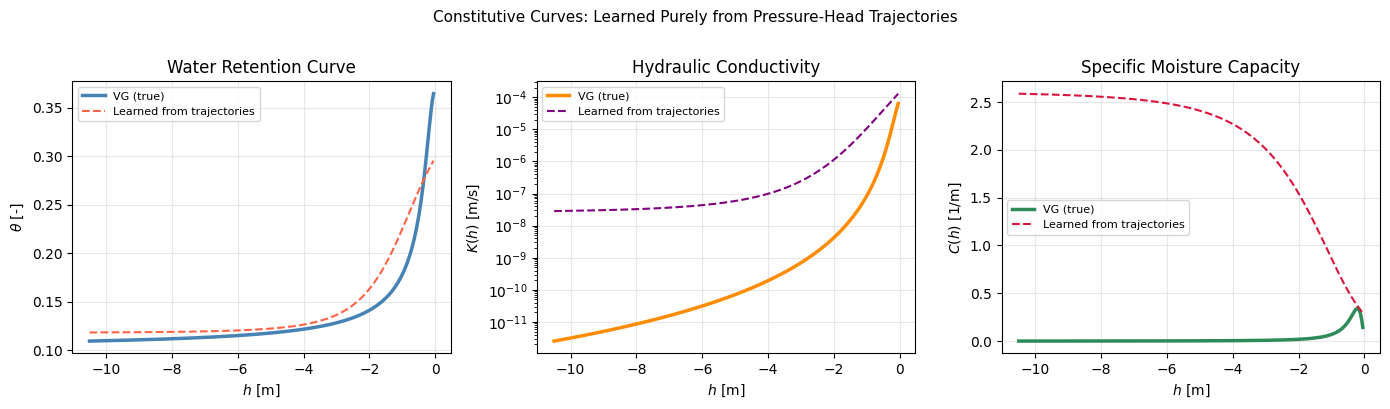

h range experienced during training: [-10.00, -0.75] m


In [24]:
# ---- Visualise the emergent constitutive curves --------------------------
#
# The network was never shown theta(h), K(h), or C(h) directly.
# These curves emerge purely from the requirement that the solver reproduce
# the observed pressure-head evolution.

h_vis   = np.linspace(h_bot * 1.05, -0.05, 300)
h_vis_t = torch.tensor(h_vis, dtype=torch.float32, device=device)

with torch.no_grad():
    th_vis, K_vis, C_vis = const_net(h_vis_t)
    th_vis = th_vis.cpu().numpy()
    K_vis  = K_vis.cpu().numpy()
    C_vis  = C_vis.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(h_vis, theta(h_vis), color='steelblue',  lw=2.5, label='VG (true)')
axes[0].plot(h_vis, th_vis,       color='tomato',     lw=1.5, ls='--', label='Learned from trajectories')
axes[0].set_xlabel('$h$ [m]'); axes[0].set_ylabel(r'$\theta$ [-]')
axes[0].set_title('Water Retention Curve'); axes[0].legend(fontsize=8)

axes[1].semilogy(h_vis, K(h_vis),      color='darkorange', lw=2.5, label='VG (true)')
axes[1].semilogy(h_vis, K_vis + 1e-20, color='purple',     lw=1.5, ls='--', label='Learned from trajectories')
axes[1].set_xlabel('$h$ [m]'); axes[1].set_ylabel('$K(h)$ [m/s]')
axes[1].set_title('Hydraulic Conductivity'); axes[1].legend(fontsize=8)

axes[2].plot(h_vis, C(h_vis), color='seagreen', lw=2.5, label='VG (true)')
axes[2].plot(h_vis, C_vis,    color='crimson',  lw=1.5, ls='--', label='Learned from trajectories')
axes[2].set_xlabel('$h$ [m]'); axes[2].set_ylabel('$C(h)$ [1/m]')
axes[2].set_title('Specific Moisture Capacity'); axes[2].legend(fontsize=8)

plt.suptitle('Constitutive Curves: Learned Purely from Pressure-Head Trajectories',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# Note: the network only sees h values in the range experienced during
# the simulation (roughly h_bot to h_top). Curves outside this range
# are extrapolation and should be interpreted with caution.
print(f'h range experienced during training: [{h_ref.min():.2f}, {h_ref.max():.2f}] m')


In [25]:
def run_hybrid_richards(h0, dt, dz, n_steps, net, store_every=5):
    """Full Richards simulation using the learned constitutive network."""
    h = torch.tensor(h0, dtype=torch.float32, device=device)
    h[0] = h_top; h[-1] = h_bot

    h_store  = [h.cpu().numpy()]
    th_store = [net(h)[0].detach().cpu().numpy()]
    t_store  = [0.0]

    with torch.no_grad():
        for step in range(n_steps):
            theta_old = net(h)[0]
            h_iter = h.clone()
            for _ in range(MAX_ITER):
                h_iter, err = picard_step_learned(h_iter, theta_old, dt, dz, net)
                if err.item() < TOL:
                    break
            h = h_iter
            if (step + 1) % store_every == 0:
                h_store.append(h.cpu().numpy())
                th_store.append(net(h)[0].detach().cpu().numpy())
                t_store.append((step + 1) * dt)

    return np.array(h_store), np.array(th_store), np.array(t_store)


print('Running hybrid solver...')
h_hyb, th_hyb, t_hyb = run_hybrid_richards(h_init, dt, dz, n_steps, const_net)
print(f'Hybrid output snapshots: {h_hyb.shape[0]}')


Running hybrid solver...
Hybrid output snapshots: 721


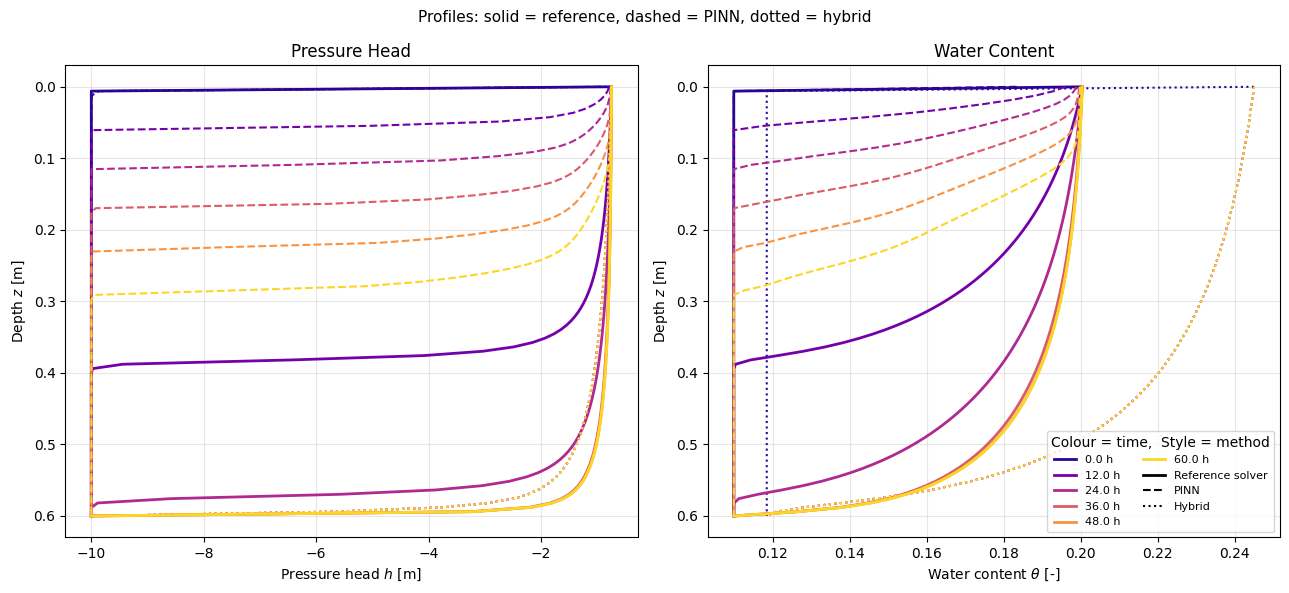

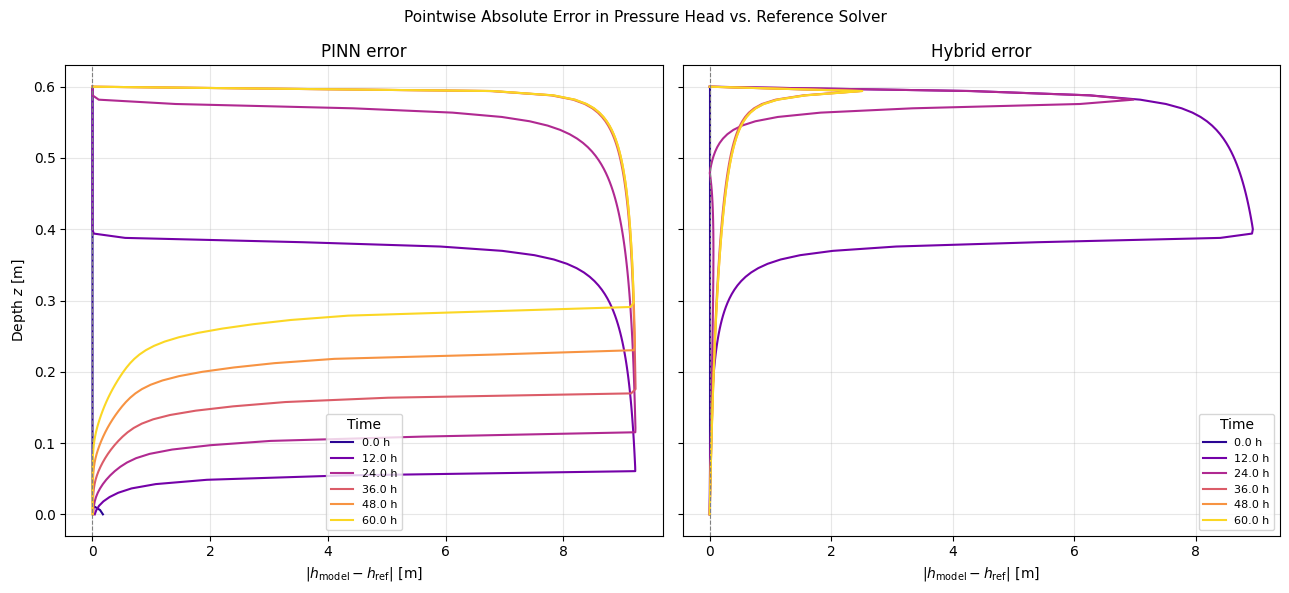

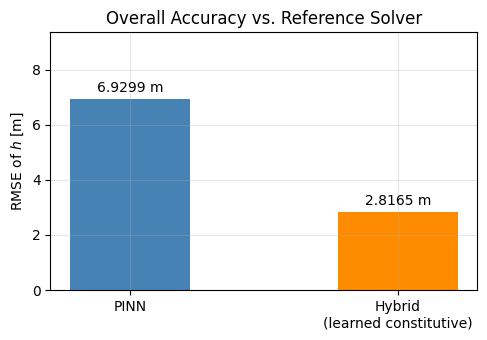

RMSE  PINN  : 6.9299 m
RMSE Hybrid : 2.8165 m


In [29]:
# =====================================================================
# Three-way comparison: Reference solver / PINN / Hybrid
#
# Figure 1 — Profile overlays
#   Each panel shows h (left) or theta (right) vs depth.
#   Colour encodes time; linestyle encodes method:
#     solid  = reference Picard solver
#     dashed = PINN
#     dotted = Hybrid (learned constitutive)
#
# Figure 2 — Pointwise absolute error |model − reference|
#   Left column: PINN error;  Right column: Hybrid error.
#   A perfect model would show a flat zero line.
#
# Figure 3 — RMSE bar chart for a quick scalar summary.
# =====================================================================

n_common  = min(h_ref.shape[0], h_hyb.shape[0])
plot_idx  = np.linspace(0, n_common - 1, 6, dtype=int)   # 6 evenly-spaced times
cmap_t    = plt.cm.plasma
colors_t  = cmap_t(np.linspace(0.05, 0.92, len(plot_idx)))

# Pre-compute PINN predictions at the reference times
h_pinn_all = np.zeros_like(h_ref[:n_common])
with torch.no_grad():
    for i, tv in enumerate(t_ref[:n_common]):
        z_q = torch.tensor(z_grid, dtype=torch.float32, device=device)
        t_q = torch.full_like(z_q, float(tv))
        h_pinn_all[i] = pinn(z_q, t_q).cpu().numpy()
th_pinn_all = np.vectorize(lambda h: theta(np.array([h]))[0])(h_pinn_all)


# ---- Figure 1: profile overlays ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

legend_handles = []
import matplotlib.lines as mlines

for ci, ti in enumerate(plot_idx):
    t_val  = float(t_ref[ti])
    color  = colors_t[ci]
    lbl    = f'{t_val/3600:.1f} h'

    # h profiles
    axes[0].plot(h_ref[ti],       z_grid, color=color, lw=2.0, ls='-')
    axes[0].plot(h_pinn_all[ti],  z_grid, color=color, lw=1.5, ls='--')
    axes[0].plot(h_hyb[ti],       z_grid, color=color, lw=1.5, ls=':')

    # theta profiles
    axes[1].plot(th_ref[ti],                   z_grid, color=color, lw=2.0, ls='-')
    axes[1].plot(theta(h_pinn_all[ti]),        z_grid, color=color, lw=1.5, ls='--')
    axes[1].plot(th_hyb[ti],                   z_grid, color=color, lw=1.5, ls=':')

    legend_handles.append(
        mlines.Line2D([], [], color=color, lw=2, label=lbl)
    )

# Linestyle legend entries
legend_handles += [
    mlines.Line2D([], [], color='k', lw=2.0, ls='-',  label='Reference solver'),
    mlines.Line2D([], [], color='k', lw=1.5, ls='--', label='PINN'),
    mlines.Line2D([], [], color='k', lw=1.5, ls=':',  label='Hybrid'),
]

for ax in axes:
    ax.invert_yaxis()
    ax.set_ylabel('Depth $z$ [m]')

axes[0].set_xlabel('Pressure head $h$ [m]')
axes[0].set_title('Pressure Head')
axes[1].set_xlabel(r'Water content $\theta$ [-]')
axes[1].set_title('Water Content')

# Single unified legend: top half = times, bottom half = methods
axes[1].legend(handles=legend_handles, fontsize=8,
               loc='lower right', ncol=2,
               title='Colour = time,  Style = method')

# Colourbar for time
sm = plt.cm.ScalarMappable(cmap=cmap_t,
                            norm=plt.Normalize(0, t_ref[n_common-1]/3600))
sm.set_array([])
#fig.colorbar(sm, ax=axes, label='Time [h]', shrink=0.7, pad=0.02)

fig.suptitle('Profiles: solid = reference, dashed = PINN, dotted = hybrid',
             fontsize=11)
plt.tight_layout()
plt.show()


# ---- Figure 2: pointwise absolute error ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for ci, ti in enumerate(plot_idx):
    color = colors_t[ci]
    lbl   = f'{t_ref[ti]/3600:.1f} h'
    axes[0].plot(np.abs(h_pinn_all[ti] - h_ref[ti]), z_grid, color=color, lw=1.5, label=lbl)
    axes[1].plot(np.abs(h_hyb[ti]      - h_ref[ti]), z_grid, color=color, lw=1.5, label=lbl)

for ax, title in zip(axes, ['PINN error', 'Hybrid error']):
    ax.invert_yaxis()
    ax.set_xlabel(r'$|h_{\mathrm{model}} - h_{\mathrm{ref}}|$ [m]')
    ax.set_title(title)
    ax.axvline(0, color='grey', lw=0.8, ls='--')
    ax.legend(fontsize=8, title='Time')

axes[0].set_ylabel('Depth $z$ [m]')
fig.suptitle('Pointwise Absolute Error in Pressure Head vs. Reference Solver',
             fontsize=11)
plt.tight_layout()
plt.show()


# ---- Figure 3: RMSE bar chart --------------------------------------------
rmse_pinn = np.sqrt(np.mean((h_pinn_all       - h_ref[:n_common]) ** 2))
rmse_hyb  = np.sqrt(np.mean((h_hyb[:n_common] - h_ref[:n_common]) ** 2))

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(['PINN', 'Hybrid\n(learned constitutive)'],
              [rmse_pinn, rmse_hyb],
              color=['steelblue', 'darkorange'], width=0.45)
ax.bar_label(bars, fmt='%.4f m', padding=3, fontsize=10)
ax.set_ylabel('RMSE of $h$ [m]')
ax.set_title('Overall Accuracy vs. Reference Solver')
ax.set_ylim(0, max(rmse_pinn, rmse_hyb) * 1.35)
plt.tight_layout()
plt.show()

print(f'RMSE  PINN  : {rmse_pinn:.4f} m')
print(f'RMSE Hybrid : {rmse_hyb:.4f} m')


## 5. Summary

| Concept | Description |
|---|---|
| **Richards equation** | Nonlinear PDE governing unsaturated flow; couples pressure head to water content and conductivity |
| **Van Genuchten model** | Empirical constitutive relations $\theta(h)$, $K(h)$, $C(h)$ with 4 soil-specific parameters |
| **Celia-Zarba solver** | Modified Picard iteration; mass-conservative, unconditionally stable for small enough $\Delta t$ |
| **PINN** | Network trained with IC/BC/PDE losses; uses autograd for PDE residual; no spatial stencil |
| **Hybrid model** | Keeps the Picard solver; replaces constitutive curves with a learned MLP; trained end-to-end |
| **Differentiable physics** | Wrapping the solver in PyTorch enables gradient flow from trajectory loss back to the constitutive network |
| **Pre-training + fine-tuning** | First match known constitutive data, then improve by matching solver trajectories |

### Key trade-offs

| Approach | Strengths | Weaknesses |
|---|---|---|
| Physics solver | Mass-conservative, interpretable, no training data | Requires accurate constitutive parameters |
| PINN | No spatial grid, meshless, flexible | Slow to train, struggles with sharp fronts |
| Hybrid | Inherits solver conservation + learns uncertain constitutive relations | More complex training; solver must be differentiable |

### Looking Ahead

- **Spatially variable soil**: give the constitutive network $(h, z)$ as input to represent a heterogeneous profile — a task essentially impossible with classical pedotransfer functions.
- **Inverse problems**: given observed water content profiles from soil sensors, backpropagate through the hybrid solver to infer soil properties.
- **Neural ODEs** (notebooks 0 and 1): the fully implicit solver is analogous to a stiff neural ODE — adjoint methods provide memory-efficient gradients for longer unrolled simulations.
- **Uncertainty quantification**: wrap the constitutive network in a Bayesian layer to propagate parameter uncertainty into hydrological predictions.
